In [ ]:
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q

<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов

# Неделя 3.

# Кейс: прогноз онлайна игроков через ETS

Возьмем данные по часовому онлайну игроков в одной из мобильных игрушек

<b>Пример взят из курса https://github.com/FUlyankin/matstat-AB </b>

In [102]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# sktime 1.1.0: сплиттеры живут в sktime.split,
# а тюнеры (Grid/Random search) — в sktime.forecasting.model_selection
from sktime.split import (
    temporal_train_test_split,
    SlidingWindowSplitter,
    ExpandingWindowSplitter,
)
from sktime.forecasting.model_selection import ForecastingGridSearchCV

from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.ets import AutoETS
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error

from sktime.forecasting.base import ForecastingHorizon

from sktime.transformations.series.boxcox import BoxCoxTransformer

from sktime.utils.plotting import plot_series, plot_correlations


plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (20,5)

In [103]:
import warnings 
warnings.filterwarnings('ignore')

### Общий алгоритм

Временные ряды отличаются некоторой спецификой. Основной проблемой при работе с такими данными является наличие утечек. На всех этапах работы с временными рядами обращайте внимание на потенциальные места, провоцирующие утечки. Ниже я собрал в одну схему некоторую последовательность действий, которые обычно следует совершить при работе с временными рядами. Разберём его по шагам.

<img src='../pic/week_3_algorithm.png' width=900, heigth=600>

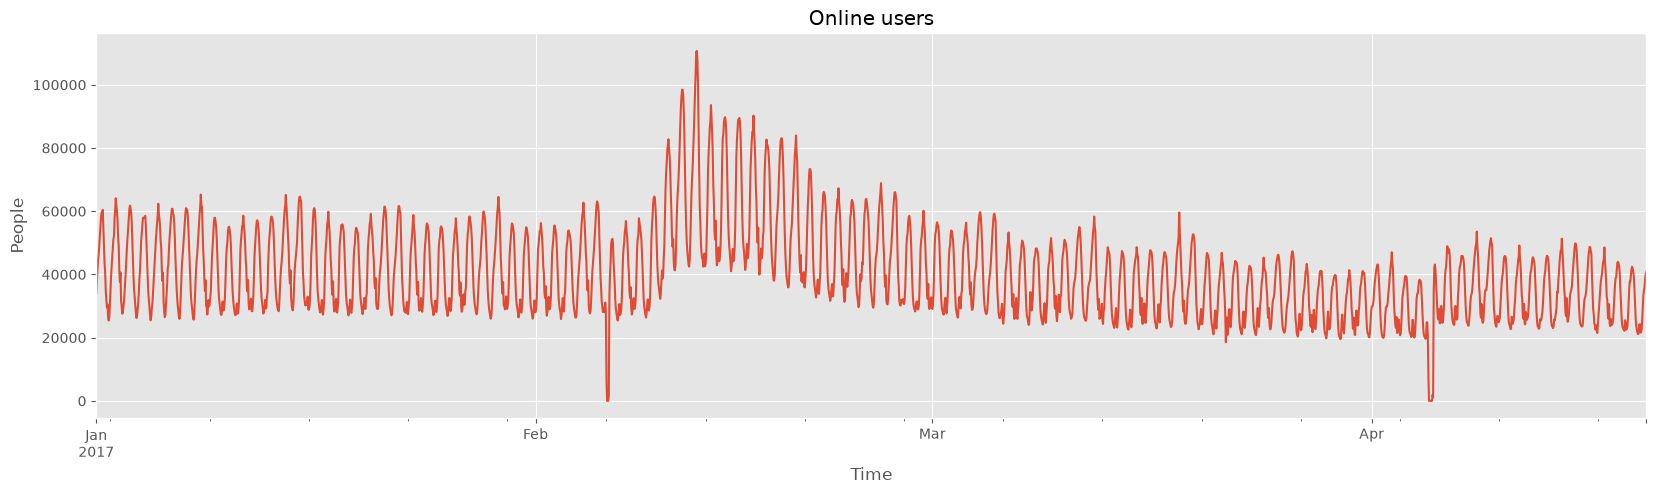

In [104]:
y = pd.read_csv(
    'https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_3/data/hour_online.csv',
    index_col=['Time'],
    parse_dates=['Time'],
    date_format='%m/%d/%y %H:%M',  # без явного формата pandas парсит построчно через dateutil
).Users

# Модели ETS в sktime ждут регулярный индекс с известной частотой:
# PeriodIndex подходит идеально. В pandas >= 2.2 алиас часа — 'h' (старый 'H' объявлен deprecated).
#
# TODO: разобраться, как правильно проставлять индекс. В данных ровно одна дыра —
# час 2017-03-12 02:00 отсутствует (переход на летнее время: часы перевели с 01:59 сразу
# на 03:00). PeriodIndex такой пропуск не подсвечивает, он просто склеивает соседние точки,
# поэтому ряд получается на 1 точку короче полной часовой сетки (2625 против 2626).
# Из-за этого в 7 из 52 фолдов кросс-валидации ниже sktime ругается
# "y_pred and y_true do not have the same row index": predict строит индекс арифметикой
# cutoff + fh (без дыры), а факт берётся из данных (с дырой), и прогноз молча выравнивается
# по факту — то есть после 12 марта сравнение идёт со сдвигом на час.
# Варианты, которые надо взвесить: reindex на pd.period_range + интерполяция пропуска;
# либо честный tz-aware DatetimeIndex ('Europe/Moscow'/UTC) вместо локального наивного времени.
# Пока оставляем как есть, чтобы не менять числа в кейсе.
y.index = pd.PeriodIndex(y.index, freq="h")
y = y.astype(np.float64)

y.plot()
plt.title('Online users')
plt.ylabel('People');

Видим сильную сезонность, возможно некоторый тренд. Амплитуда сезонной компоненты менялась. Выбросы, особенно до уровня 0 (технический сбой или плановые отключения серверов). Структурный сдвиг в феврале и плавное его затухание.

In [105]:
# зададим размер тестовой выборки в 1 неделю
test_size = 7*24

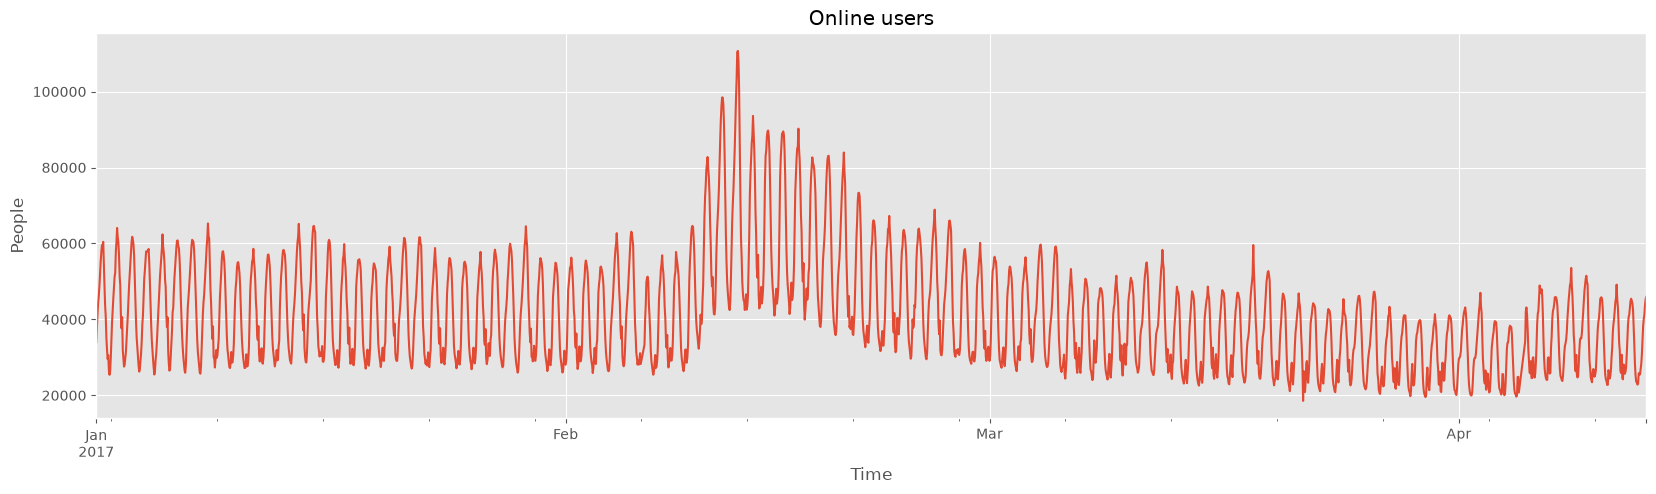

In [106]:
# Убираем выбросы вниз и линейно интерполируем по соседним точкам
y[y<10000] = np.nan
y = y.interpolate()

y_train, y_test = temporal_train_test_split(y, test_size=test_size)
y_train.plot()


plt.title('Online users')
plt.ylabel('People');

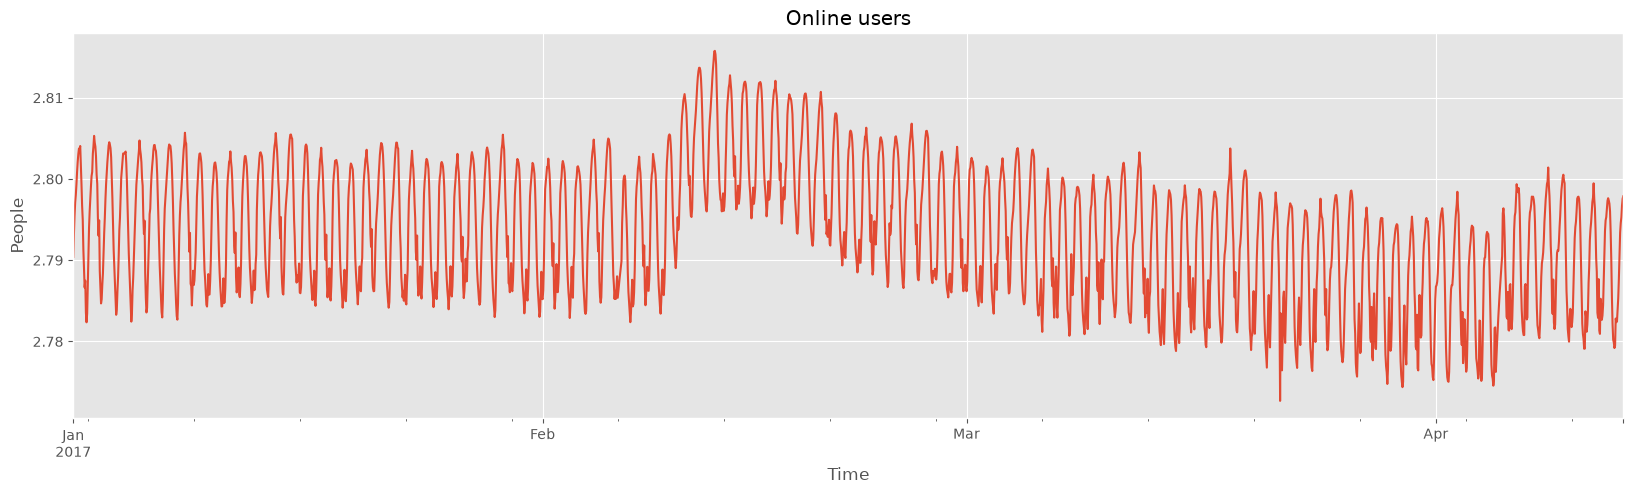

In [107]:
# посмотрим на результат преобразования Бокса-Кокса
transformer = BoxCoxTransformer()
y_train_hat = transformer.fit_transform(y_train)


y_train_hat.plot()

plt.title('Online users')
plt.ylabel('People');

In [108]:
transformer.lambda_

np.float64(-0.34897535771060867)

Зададим сетку разных моделей ETS

In [109]:
fh = ForecastingHorizon(list(range(1, test_size+1)))

# период сезонной компоненты 24 часа (лучше передавать в явном виде)
forecaster = AutoETS(sp=24)
param_grid = {
    'error': ['add', 'mul'],
    'trend': [None, 'add'],
    'seasonal': ['add','mul'],
#    'damped_trend': ['add','mul'],
}

In [110]:
len(y_train_hat)

2457

Рассмотрим кросс-валидацию скользящим окном и переберем все модели из нашего списка

In [111]:
cv = SlidingWindowSplitter(
    window_length=1000,
    step_length=25,
    fh=fh)

# В sktime 1.1.0 параметра n_jobs у тюнеров больше нет (удалён в 0.27.0).
# Параллелизм задаётся парой backend / backend_params.
gscv = ForecastingGridSearchCV(
    forecaster=forecaster,
    param_grid=param_grid,
    cv=cv,
    verbose=1,
    backend="loky",
    backend_params={"n_jobs": -1},
    )
gscv.fit(y_train_hat);

Fitting 52 folds for each of 8 candidates, totalling 416 fits


/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/3/.venv/lib/python3.11/site-packages/sktime/performance_metrics/forecasting/_base.py:658: UserWarning: y_pred and y_true do not have the same row index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/3/.venv/lib/python3.11/site-packages/sktime/performance_metrics/forecasting/_base.py:658: UserWarning: y_pred and y_true do not have the same row index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/3/.venv/lib/python3.11/site-packages/sktime/performance_metrics/forecasting/_base.py:658: UserWarning: y_pred and y_true do not have the same row index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(
/Users/a.p.chikov/PycharmProjects/Времен

В рамках sktime нормально не реализована возможность посмотреть на качество всех 8 моделей. Поэтому напишем код, который сформирует для нас такую таблицу.

In [112]:
# Вынесем разбор cv_results_ в функцию — она понадобится ещё раз ниже.
# Имена колонок в sktime 1.1.0: mean_test_<Metric>, mean_fit_time, mean_pred_time,
# params, rank_test_<Metric>. Метрика по умолчанию — MeanAbsolutePercentageError.
def cv_results_table(gscv, metric="MeanAbsolutePercentageError"):
    results_df = pd.DataFrame(gscv.cv_results_)

    # словарь гиперпараметров из колонки params раскладываем по отдельным колонкам
    params_df = pd.json_normalize(results_df['params'])
    results_df = pd.concat([results_df.drop(columns=['params']), params_df], axis=1)

    # сортируем по рангу метрики на тесте (1 — лучшая модель)
    results_df = results_df.sort_values(by=f'rank_test_{metric}')

    # переименовываем по имени, а не по позиции: набор гиперпараметров в сетке меняется
    return results_df.rename(columns={
        f'mean_test_{metric}': "Mean Test MAPE",
        'mean_fit_time': "Mean Fit Time",
        'mean_pred_time': "Mean Prediction Time",
        f'rank_test_{metric}': "Rank",
        'error': "Error",
        'trend': "Trend",
        'seasonal': "Seasonal",
    })


# выводим результаты
cv_results_table(gscv)

,Mean Test MAPE,Mean Fit Time,Mean Prediction Time,Rank,Error,Seasonal,Trend
4,0.001047,0.189385,0.005038,1.0,mul,add,None
0,0.001047,0.150824,0.006031,2.0,add,add,None
6,0.001049,0.255756,0.005826,3.0,mul,mul,None
2,0.001049,0.222356,0.005234,4.0,add,mul,None
1,0.001108,0.205759,0.005242,5.0,add,add,add
3,0.001110,0.264474,0.005997,6.0,add,mul,add
7,0.001112,0.309683,0.005429,7.0,mul,mul,add
5,0.001115,0.241726,0.005330,8.0,mul,add,add


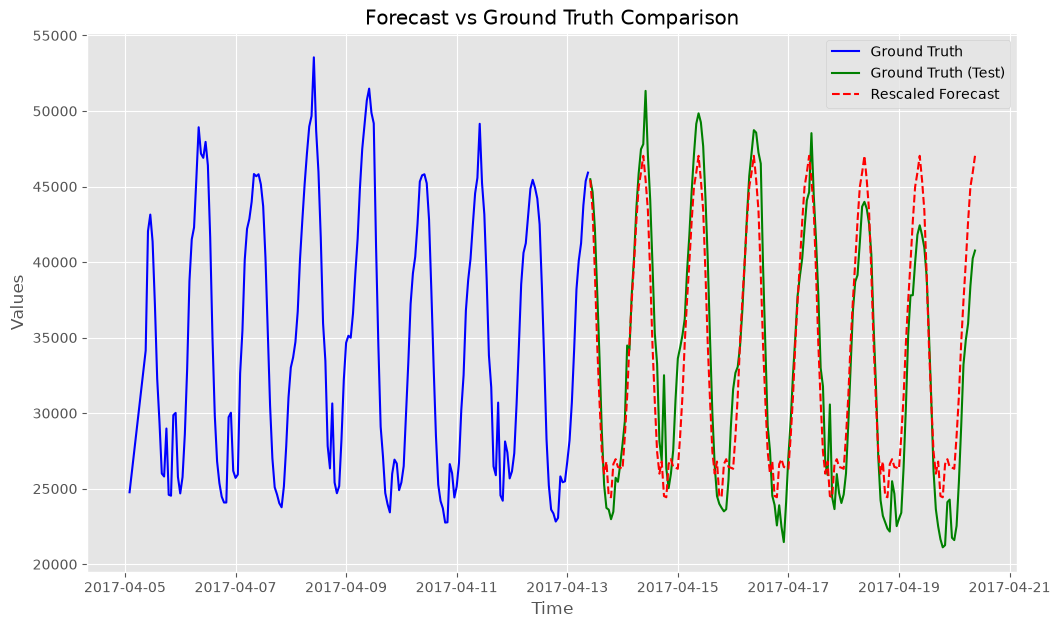

In [113]:
# Шаг 1: Определить лучшую модель
# (Предполагается, что `gscv` - это ваш объект ForecastingGridSearchCV)
best_forecaster = gscv.best_forecaster_

best_forecaster.fit(y_train_hat)

# Шаг 2: Генерируем прогноз с использованием лучшей модели
# Предполагается, что `fh` - это ваш горизонт прогнозирования
forecast = best_forecaster.predict(fh)

# Шаг 3: Изменение масштаба прогноза (если ваш трансформатор поддерживает inverse_transform)
rescaled_forecast = transformer.inverse_transform(forecast)

# Выбор последних 200 наблюдений из y_train, чтобы на графики 
# не отображалась вся предыстория
y_train_last = y_train.iloc[-200:]

plt.figure(figsize=(12, 7))

# Plotting the last 200 observations of y_train
plt.plot(y_train_last.index.to_timestamp(), y_train_last, label='Ground Truth', color='blue')

# Plotting the actual test data
plt.plot(y_test.index.to_timestamp(), y_test, label='Ground Truth (Test)', color='green')

# Plotting the rescaled forecast
plt.plot(forecast.index.to_timestamp(), rescaled_forecast, label='Rescaled Forecast', linestyle='--', color='red')

plt.legend()
plt.title('Forecast vs Ground Truth Comparison')
plt.xlabel('Time')
plt.ylabel('Values')
plt.show()

In [114]:
# сохраним прогнозы этой модели
forecast_standard = rescaled_forecast.copy()

Посмотрим на остатки.

Остатки явно не те, которые мы бы хотели видеть. Особенно плохо начиная с 2017-03-15, где наблюдается резкая смена поведения остатков.

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='Users'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

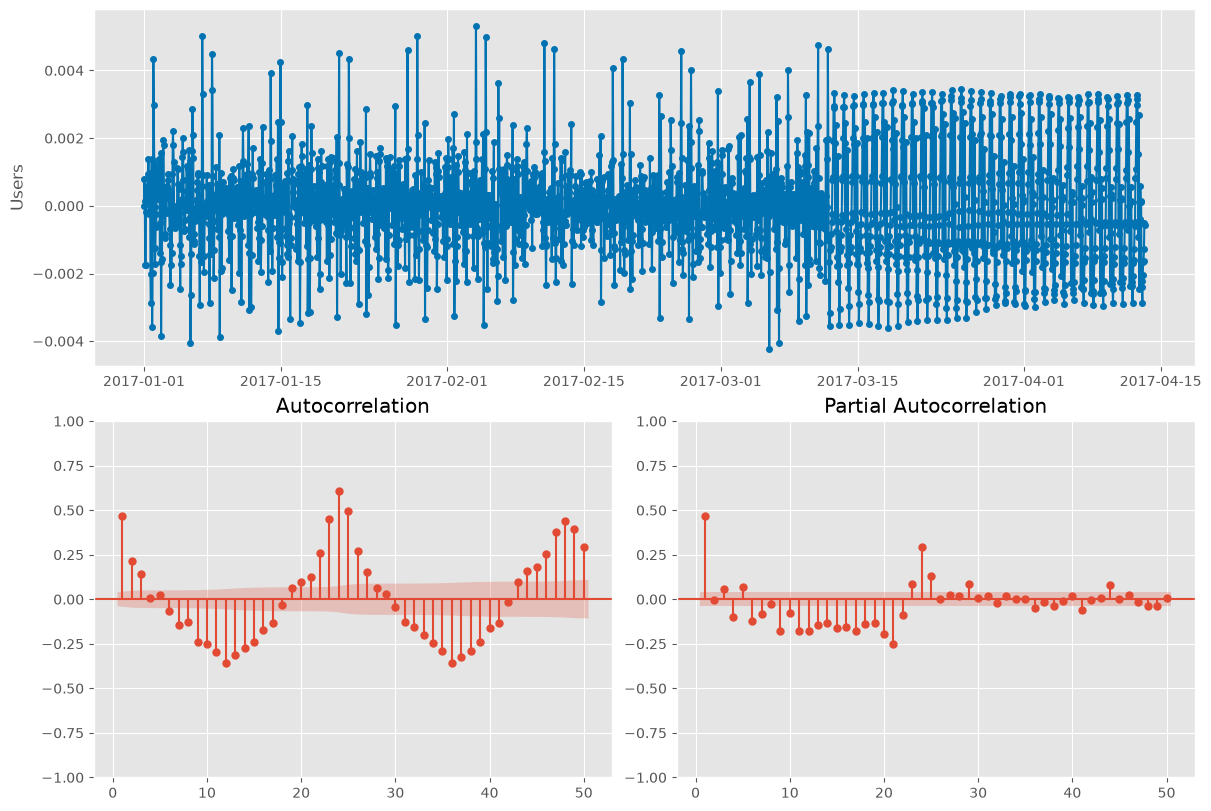

In [115]:
residuals = best_forecaster.predict_residuals()
plot_correlations(residuals, lags=50, zero_lag=False)

Можно написать тесты Бокса-Пирса и Льюнга-Бокса руками на основе автокореляций.

Хотя в нашем случае по графику уже очевидно, что корреляция в остатках есть.

In [116]:
from statsmodels.tsa.stattools import acf
from scipy.stats import chi2

# тут можно было взять и побольше, лучше 30 из-за сезонности=24
n_lags = 20
n_obs = len(residuals)
autocorrelations = acf(residuals, nlags=n_lags)[1:]
box_pirece_statistics = n_obs * (autocorrelations**2).sum()
box_pirece_statistics
box_pirece_pval = 1 - chi2.cdf(box_pirece_statistics, df=n_lags)

f"Box-Pierce test. Statistics: {box_pirece_statistics}, p-value: {box_pirece_pval}"

'Box-Pierce test. Statistics: 2335.044767168594, p-value: 0.0'

In [117]:
denominators = n_obs - np.arange(1, n_lags+1)

In [118]:
n_lags = 20
n_obs = len(residuals)
autocorrelations = acf(residuals, nlags=n_lags)[1:]
ljung_box_statistics = n_obs * (n_obs +2) * ((autocorrelations**2 / denominators)).sum()
ljung_box_statistics
ljung_box_pval = 1 - chi2.cdf(ljung_box_statistics, df=n_lags)

f"Ljung-Box test. Statistics: {ljung_box_statistics}, p-value: {ljung_box_pval}"

'Ljung-Box test. Statistics: 2345.506822811834, p-value: 0.0'

То же самое можно сделать с помощью библиотеки statsmodels.

In [119]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# строчки идут с увеличением колличества автокорреляций, учитываемых в статистиках
acorr_ljungbox(residuals, boxpierce=True, lags=n_lags)

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,537.357275,7.085236e-119,536.701695,9.839565e-119
2,651.257591,3.812510e-142,650.416731,5.804988e-142
3,701.459209,1.013041e-151,700.516272,1.622154e-151
4,701.585102,1.581311e-150,700.641859,2.530798e-150
5,703.104343,1.047206e-149,702.156774,1.678487e-149
6,713.537634,7.302135e-151,712.556122,1.189571e-150
7,764.954395,6.761482e-161,763.784696,1.208875e-160
8,803.243533,4.115584e-168,801.918125,7.945003e-168
9,941.362911,7.547033e-197,939.419644,1.979780e-196
10,1094.358729,8.679798e-229,1091.668837,3.298715e-228


Попробуем сделать еще одно преобразование временного ряда. Позже это будет называться взятием сезонных разностей. В каком-то смысле это удаление сезонной компоненты.

$\hat{y}_t = y_t - y_{t-24}$

In [120]:
class DiffTransformer:
    def __init__(self, n_lags):
        self.n_lags = n_lags 

    def fit_transform(self, x: pd.Series):
        return (x - x.shift(self.n_lags)).dropna() + 1 # сдвинем данные на 1, это повышает устойчивость численных оценок параметров
    
    def inverse_transform(self, x: pd.Series, init_values:list):

        assert len(init_values) == self.n_lags

        x = x - 1
        for value in x.values:

            init_values.append(init_values[-self.n_lags] + value) 

        init_values = init_values[self.n_lags:]

        result = pd.Series(init_values, index = x.index) 

        return result
    


Применим функцию сезонного дифференцирования к нашему ряду и посмотрим на результат.

In [121]:
diff_transformer = DiffTransformer(n_lags=24)

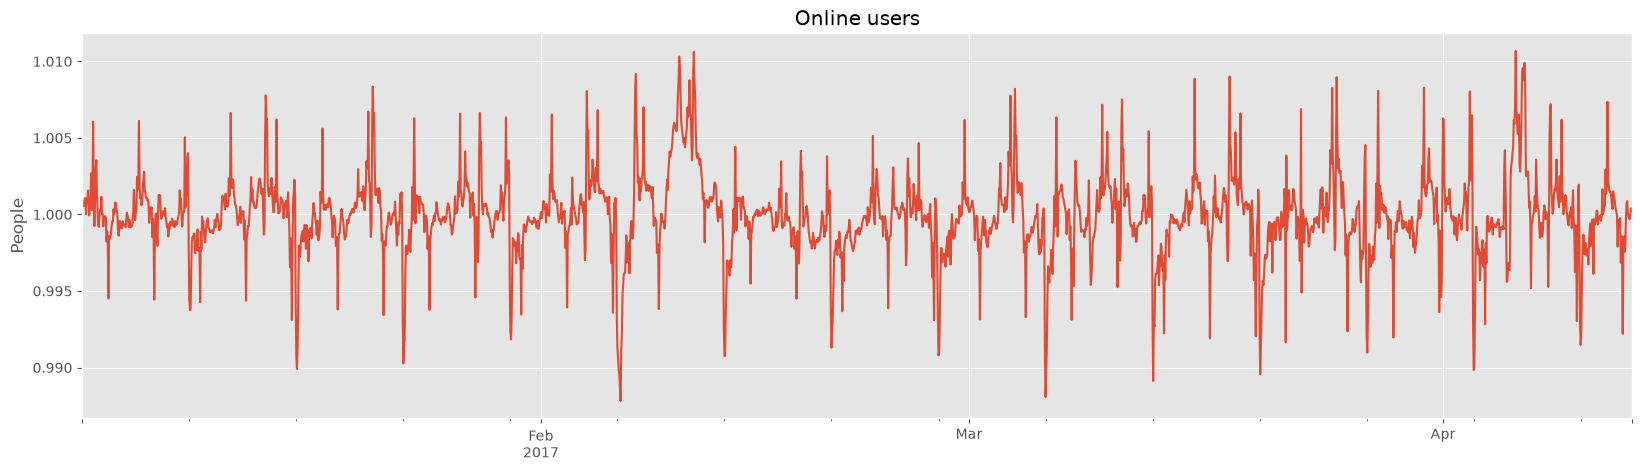

In [122]:
y_train_hat_diff = diff_transformer.fit_transform(y_train_hat)

y_train_hat_diff.plot()

plt.title('Online users')
plt.ylabel('People');

<Axes: >

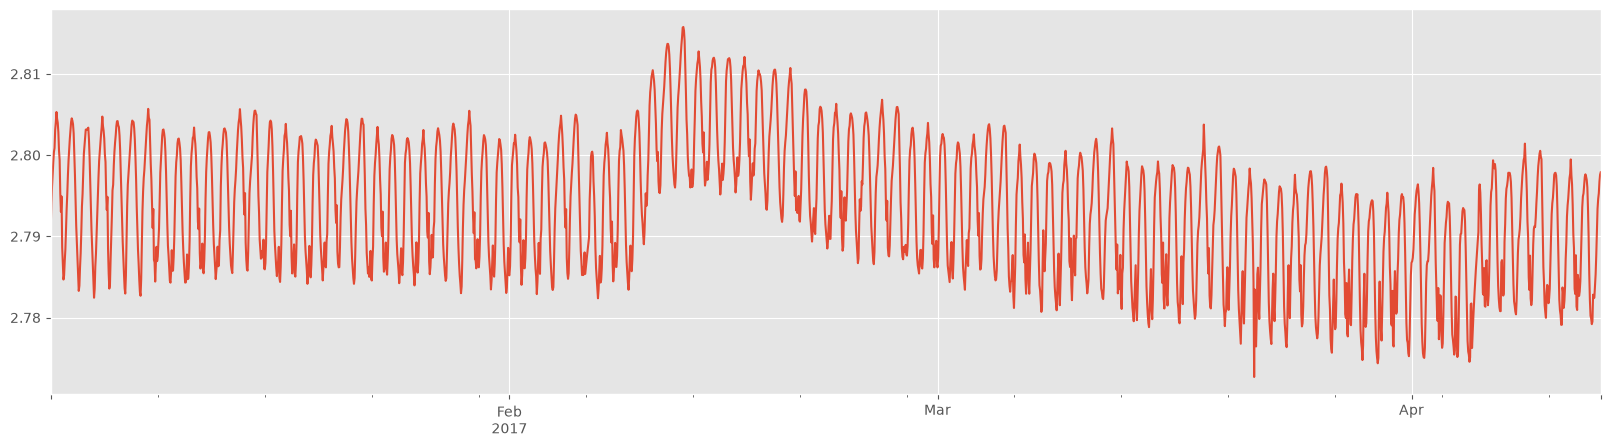

In [123]:
# возврат к исходному ряду
diff_transformer.inverse_transform(y_train_hat_diff, y_train_hat.iloc[:24].to_list()).plot()

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='Users'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

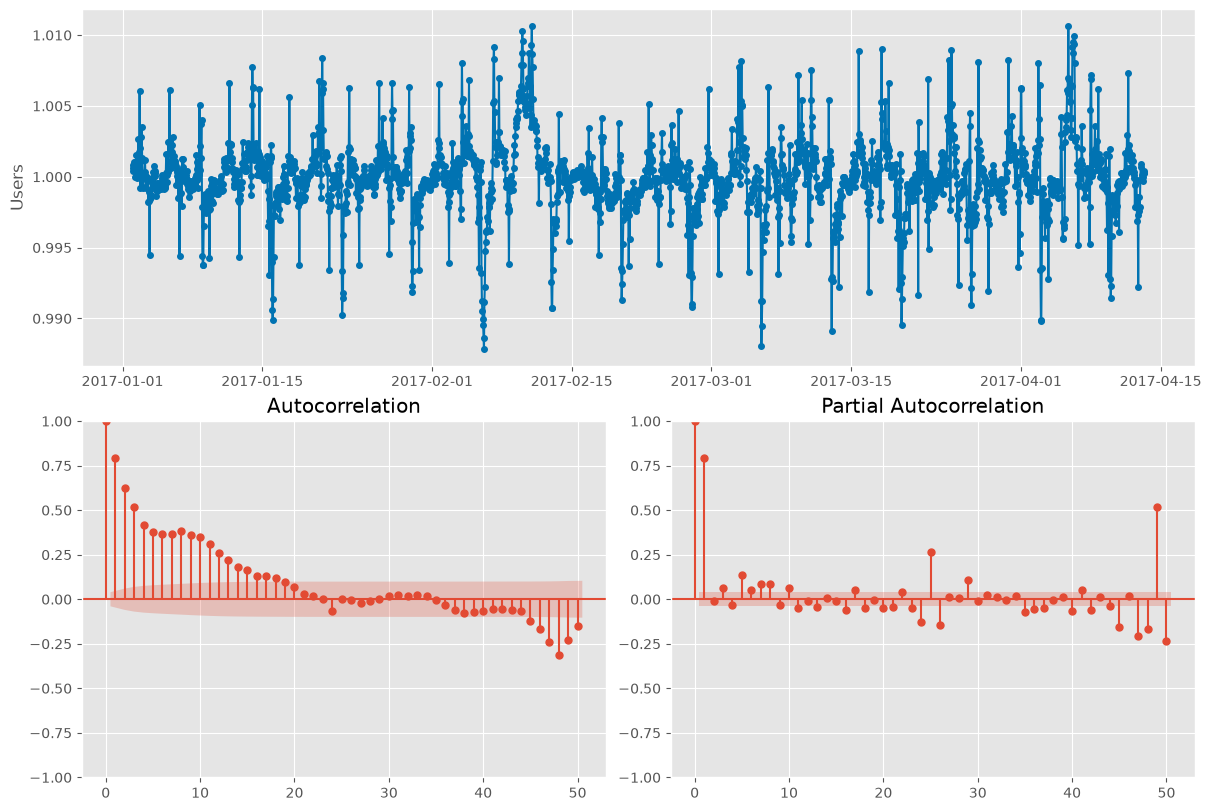

In [124]:
plot_correlations(y_train_hat_diff, lags=50)

In [125]:
forecaster = AutoETS(sp=24)
param_grid = {
    'error': ['add', 'mul'],
    'trend': [None, 'add'],
    'seasonal': ['add'], # здесь можно добавить None и 'mul'
}

cv = SlidingWindowSplitter(
    window_length=1000,
    step_length=25,
    fh=fh)
gscv = ForecastingGridSearchCV(
    forecaster=forecaster,
    param_grid=param_grid,
    cv=cv,
    verbose=1,
    backend="loky",
    backend_params={"n_jobs": -1},
    )


gscv.fit(y_train_hat_diff);

Fitting 51 folds for each of 4 candidates, totalling 204 fits


/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/3/.venv/lib/python3.11/site-packages/sktime/performance_metrics/forecasting/_base.py:658: UserWarning: y_pred and y_true do not have the same row index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/3/.venv/lib/python3.11/site-packages/sktime/performance_metrics/forecasting/_base.py:658: UserWarning: y_pred and y_true do not have the same row index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/3/.venv/lib/python3.11/site-packages/sktime/performance_metrics/forecasting/_base.py:658: UserWarning: y_pred and y_true do not have the same row index. This may indicate incorrect objects passed to the metric. Indices of y_true will be used for y_pred.
  warn(
/Users/a.p.chikov/PycharmProjects/Времен

In [126]:
# Тот же разбор cv_results_, что и выше, — сравниваем модели после дифференцирования
cv_results_table(gscv)

,Mean Test MAPE,Mean Fit Time,Mean Prediction Time,Rank,Error,Seasonal,Trend
2,0.002512,0.152623,0.003634,1.0,mul,add,None
0,0.002512,0.134253,0.004155,2.0,add,add,None
1,0.002611,0.184213,0.003620,3.0,add,add,add
3,0.002621,0.228924,0.003448,4.0,mul,add,add


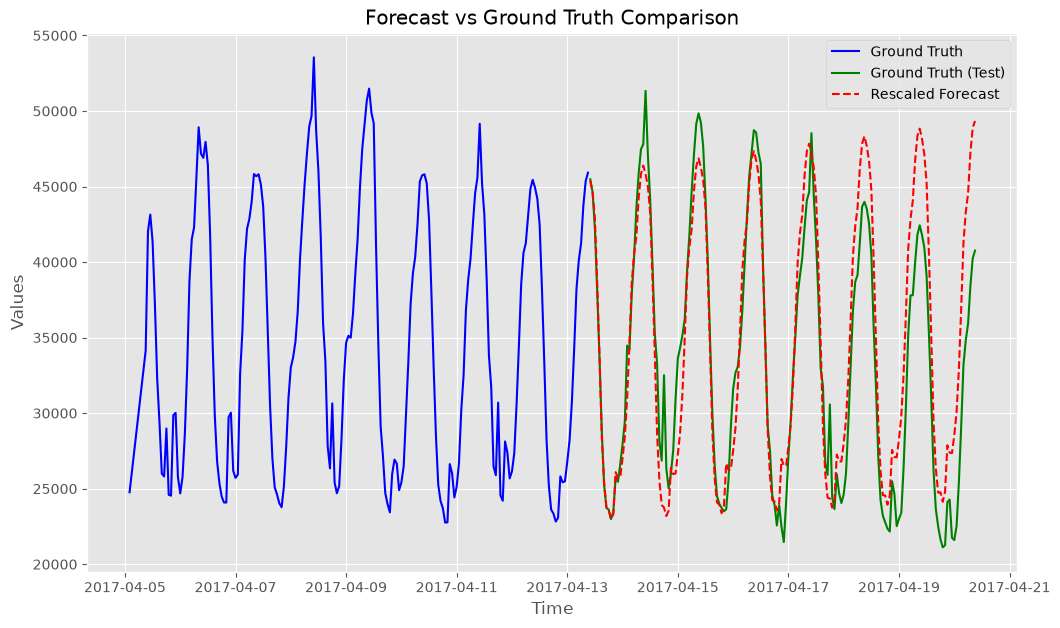

In [127]:
best_forecaster = gscv.best_forecaster_

best_forecaster.fit(y_train_hat_diff)

forecast = best_forecaster.predict(fh)

trended_forecast = diff_transformer.inverse_transform(forecast, y_train_hat.tail(24).to_list())

rescaled_forecast = transformer.inverse_transform(trended_forecast)

y_train_last = y_train.iloc[-200:]

plt.figure(figsize=(12, 7))

plt.plot(y_train_last.index.to_timestamp(), y_train_last, label='Ground Truth', color='blue')

plt.plot(y_test.index.to_timestamp(), y_test, label='Ground Truth (Test)', color='green')

plt.plot(forecast.index.to_timestamp(), rescaled_forecast, label='Rescaled Forecast', linestyle='--', color='red')

plt.legend()
plt.title('Forecast vs Ground Truth Comparison')
plt.xlabel('Time')
plt.ylabel('Values')
plt.show()

In [128]:
forecast_diff = rescaled_forecast.copy()

(<Figure size 1200x800 with 3 Axes>,
 array([<Axes: ylabel='Users'>,
        <Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

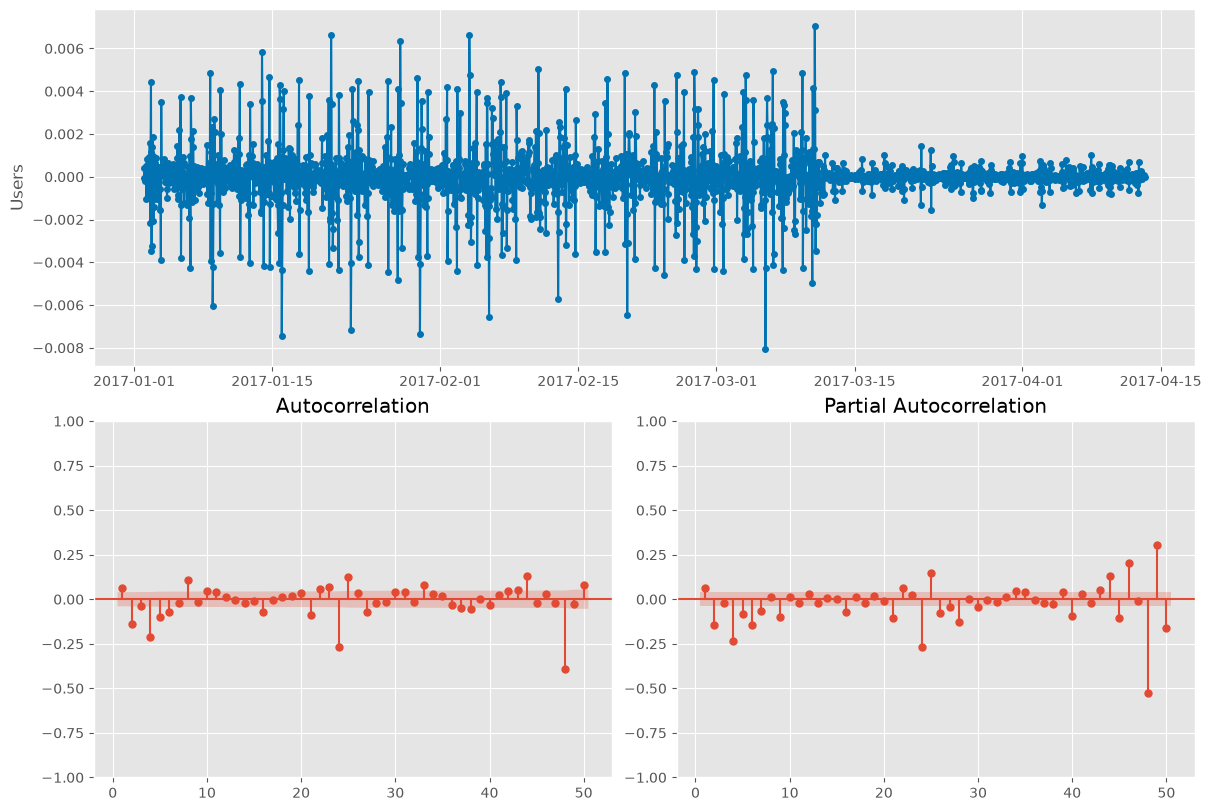

In [129]:
residuals = best_forecaster.predict_residuals()
plot_correlations(residuals, lags=50, zero_lag=False)

In [130]:
mean_absolute_percentage_error(y_true=y_test, y_pred=forecast_standard)

np.float64(0.08453151148835622)

In [131]:
mean_absolute_percentage_error(y_true=y_test, y_pred=forecast_diff)

np.float64(0.08761002624759795)

Несмотря на то, что ошибки выглядят визуально лучше, но на тестовой выборке качество второй модели хуже. Графики остатков нуэно смотреть с учетом величины остатков. На втором граке значения остатков по модулю выше, т.е. больше будет дисперсия остатков.

## Итог кейса

Несмотря на то, что после сезонного дифференцирования остатки визуально выглядят лучше, на тестовой выборке качество (MAPE) второй модели оказалось **хуже**. Графики остатков нужно читать с учётом их масштаба: во втором случае остатки по модулю крупнее, то есть их дисперсия выше. Главный урок кейса — **красивые остатки не гарантируют лучший прогноз на тесте**; ориентируйтесь на честную оценку на отложенной выборке.